# Седловые задачи (10 баллов)

In [281]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from tqdm import tqdm
import itertools
from scipy.stats import multivariate_normal

__Задача 1.__ Рассмотрим игру двух игроков:

- __Игрок 1 (полицейский)__ стремится минимизировать некоторую величину (ущерб);
- __Игрок 2 (вор)__ стремится максимизировать некоторую величину (нанесенный ущерб).

Если у каждого игрока конечное число чистых стратегий — $d$, то игру можно представить через матрицу выигрышей $A \in \mathbb{R}^{d \times d}$, где элемент $A_{ij}$ означает выигрыш вора, если он выбирает стратегию $j$, а полицейский — стратегию $i$. Проигрыш первого игрока равен выигрышу второго.

В общем случае игроки могут применять смешанные стратегии, то есть выбирать свои действия случайно в соответствии с вероятностным распределением. Обозначим:

- $x \in \mathcal{X} = \left\{x \in \mathbb{R}^d \mid x \succeq 0,~ \boldsymbol{1}^\top x = 1 \right\}$ — распределение полицейского;
- $y \in \mathcal{Y} = \left\{y \in \mathbb{R}^d \mid y \succeq 0,~ \boldsymbol{1}^\top y = 1 \right\}$ — распределение вора.

Тогда ожидаемый выигрыш вора равен:
$$
f(x, y) = x^\top A y = \sum_{i=1}^d \sum_{j=1}^d x_i A_{ij} y_j.
$$

Представим город как квадратную сетку $n \times n$. В каждой из $d = n^2$ ячеек расположены:

- Дом, имеющий ценность для вора $w_j \geq 0$;
- Полицейская будка.

Каждую ночь:

- Вор выбирает дом $j$ для ограбления;
- Полицейский выбирает будку $i$ для дежурства.

Пусть $\mathrm{dist}(i, j)$ — расстояние между ячейками $i$ и $j$. Чем дальше вор от полицейского — тем ниже шанс быть пойманным. Зададим эту зависимость экспоненциально:

$$
\mathbb{P}(\text{поимка} \mid i, j) = \exp \left(-\alpha \cdot \mathrm{dist}(i, j)\right), \quad \alpha > 0.
$$

Тогда ожидаемая прибыль вора при чистых стратегиях $(i, j)$ равна:

$$
A_{ij} = w_j \left(1 - \exp(- \alpha \cdot \mathrm{dist}(i, j)) \right).
$$

__а) (2 балла)__ Допишите метрику (выберите на свое усмотрение).

In [282]:
def to_descartes(i, n):

    x, y = i%n, i//n
    return x, y

def dist(i, j, n):
    """
    Вычисляет расстояние между ячейками i и j.
    
    Параметры:
        i (int): Индекс полицейского
        j (int): Индекс вора
        n (int): Размер сетки города
        
    Возвращает:
        dist (float): Расстояние
    """
    
    # YOUR CODE HERE
    xi, yi = to_descartes(i, n)
    xj, yj = to_descartes(j, n)
    
    return np.sqrt((xi-xj)**2 + (yi-yj)**2)

Допишите функцию `matrix_game`. Предполагается, что чем ближе дом к центру, тем ценность его выше.

In [283]:
def matrix_game(n, alpha, dist):
    """
    Создает матрицу игры A и веса домов w.
    
    Параметры:
        n (int): Размер сетки города
        alpha (float): Параметр экспоненциального затухания вероятности поимки
        dist (Callable): Функция расстояния
    
    Возвращает:
        A (np.array): Матрица выигрышей
        w (np.array): Веса домов
    """
    
    mean = [0, 0]
    cov = [[1, 0], [0, 1]]
    sample_space = np.linspace(-2.5, 2.5, n)
    map = np.dstack(np.meshgrid(sample_space, sample_space))

    w_map = multivariate_normal(mean, cov).pdf(map)
    w = w_map.reshape(n**2)

    #w = np.abs(n**2-dist(np.arange(n**2), np.full(n**2, n**2//2), n))

    index = np.arange(n**2)
    index1, index2 = np.meshgrid(index, index)
    D = dist(index1, index2, n)
    #print(D)

    A = w * (1 - np.exp(-alpha*D))
    return A, w

In [284]:
n=25
A, w = matrix_game(n, 0.1, dist)
w_map = w.reshape((n, n))

Визуализируйте на 2D и 3D графике полученные веса для $n = 25$.

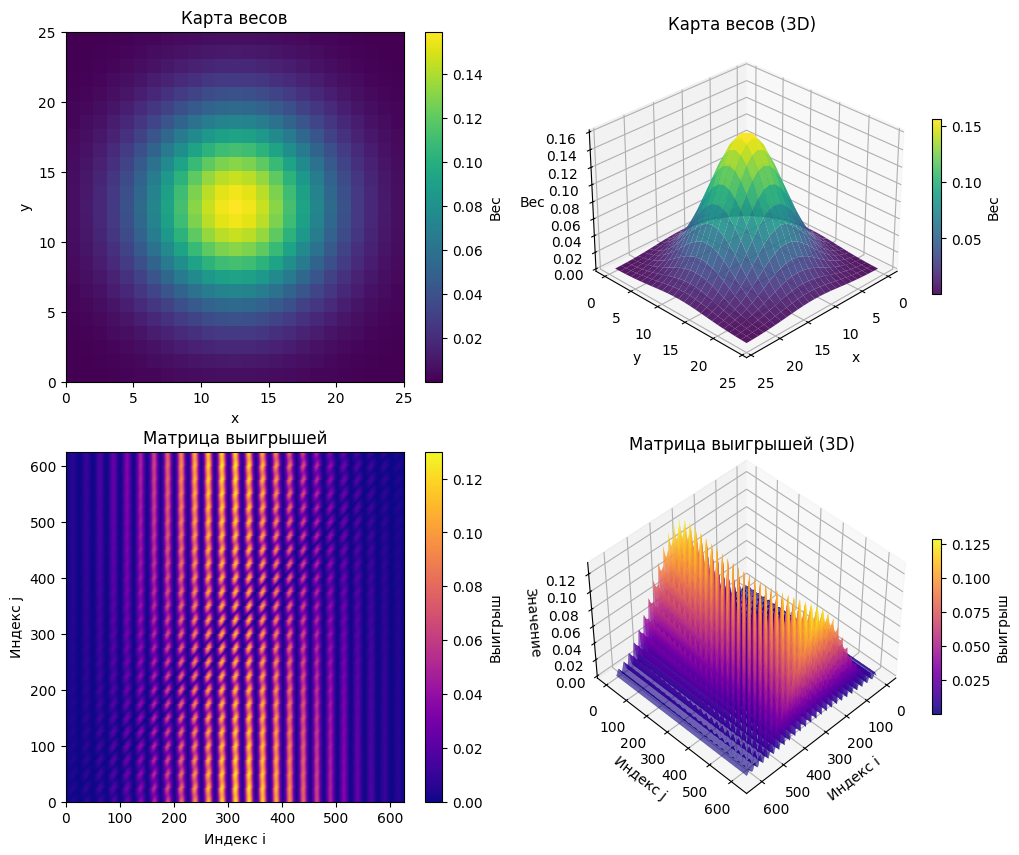

In [285]:
x_w = np.arange(n)
y_w = np.arange(n)
X_w, Y_w = np.meshgrid(x_w, y_w)

x_a = np.arange(n**2)
y_a = np.arange(n**2)
X_a, Y_a = np.meshgrid(x_a, y_a)

fig = plt.figure(figsize=(12, 10))

ax1 = fig.add_subplot(2, 2, 1)
im1 = ax1.imshow(w_map, extent=[0, n, 0, n], 
                 origin='lower', cmap='viridis', aspect='auto')
ax1.set_title('Карта весов')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
plt.colorbar(im1, ax=ax1, label='Вес')

ax2 = fig.add_subplot(2, 2, 2, projection='3d')
surf1 = ax2.plot_surface(X_w, Y_w, w_map, cmap='viridis', edgecolor='none', alpha=0.9, rstride=1, cstride=1)
ax2.set_title('Карта весов (3D)')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('Вес')
fig.colorbar(surf1, ax=ax2, shrink=0.5, label='Вес')
ax2.view_init(elev=30, azim=45)

ax3 = fig.add_subplot(2, 2, 3)
im2 = ax3.imshow(A, extent=[0, n**2, 0, n**2], origin='lower', cmap='plasma', aspect='auto')
ax3.set_title('Матрица выигрышей')
ax3.set_xlabel('Индекс i')
ax3.set_ylabel('Индекс j')
plt.colorbar(im2, ax=ax3, label='Выигрыш')

ax4 = fig.add_subplot(2, 2, 4, projection='3d')
surf2 = ax4.plot_surface(X_a, Y_a, A, cmap='plasma', edgecolor='none', alpha=0.9, rstride=1, cstride=1)
ax4.set_title('Матрица выигрышей (3D)')
ax4.set_xlabel('Индекс i')
ax4.set_ylabel('Индекс j')
ax4.set_zlabel('Значение')
fig.colorbar(surf2, ax=ax4, shrink=0.5, label='Выигрыш')
ax4.view_init(elev=45, azim=45)

plt.show()

__б) (1 балл)__ Экстраградиентный метод предназначен для решения седловых задач, а зеркальный спуск — для лучшего учета <<геометрии>> задачи. Попробуем объединить эти две идеи и получим следующий метод:

$$\begin{align*}
x^{k + 1/2} &= \arg \min_{x \in \mathcal{X}} (\gamma \langle \nabla_x f(x^k, y^k), x \rangle + V(x,x^k)) \\
y^{k + 1/2} &= \arg \min_{y \in \mathcal{Y}} (\gamma \langle -\nabla_y f(x^k, y^k), y \rangle + V(y,y^k)) \\
x^{k + 1} &= \arg \min_{x \in \mathcal{X}} (\gamma \langle \nabla_x f(x^{k + 1/2}, y^{k + 1/2}), x \rangle + V(x,x^k)) \\
y^{k + 1} &= \arg \min_{y \in \mathcal{Y}} (\gamma \langle -\nabla_y f(x^{k + 1/2}, y^{k + 1/2}), y \rangle + V(y,y^k)).
\end{align*}$$

Для краткости введем обозначения:

$$
z = \binom{x}{y} \quad F(z) = F(x, y) = \binom{\nabla_x f(x, y)}{-\nabla_y f(x, y)}
$$

В новых обозначениях метод выше можно переписать как

$$\begin{align*}
z^{k + 1/2} &= \arg \min_{z \in \mathcal{Z}} (\gamma \langle F(z^k), z \rangle + V(z,z^k)) \\
z^{k + 1} &= \arg \min_{z \in \mathcal{Z}} (\gamma \langle F(z^{k + 1/2}), z \rangle + V(z,z^k)),
\end{align*}$$

где $\mathcal{Z} = \mathcal{X} \times \mathcal{Y}$.

В качестве дивергенции Брэгмана рассмотрим расстояние Кульбака-Лейблера:

$$
V(z, z^k) = \mathrm{KL} \left(x \parallel x^k \right) + \mathrm{KL} \left(y \parallel y^k \right).
$$

Найдите константу Липшица оператора $F$.

__Решение__

Найдем $F$ в явном виде:

$$
f = x^\top Ay = \langle x, Ay\rangle \Rightarrow \nabla_x f = Ay, \nabla_y f = A^\top x \implies F(z = (x, y)^\top) = \binom{Ay}{A^\top x}
$$

Тогда проведем оценку

$$
\Vert F (z_2) - F(z_1) \Vert^2 = \Vert A\Vert^2 \Vert y_2 - y_1 \Vert^2 + \Vert A^\top \Vert^2 \Vert x_2 - x_1 \Vert^2 = \left/ \Vert A \Vert = \Vert A^\top \Vert \right/ = \Vert A \Vert^2 \Vert z_2 - z_1 \Vert^2  
$$

Таким образом $L = \Vert A \Vert$

Найдите константу Липшица.

In [286]:
# Ваше решение (Code)
L = np.linalg.norm(A)
L

np.float64(21.422393409563874)

__в) (1 балл)__ В качестве метрики будем использовать $\text{gap}$, которая оценивает близость к седловой точке:

$$
\text{gap}(x^k, y^k) = \max_{y \in \mathcal{Y}} f(x^k, y) - \min_{x \in \mathcal{X}} f(x, y^k).
$$

Допишите функцию, подсчитывающую эту метрику.  

In [287]:
def compute_gap(x, y, A):
    """
    Вычисляет gap(x, y)
    
    Параметры:
        x (np.array): Вектор полицейского
        y (np.array): Вектор вора
        A (np.array): Матрица выигрышей
    
    Возвращает:
        gap (float): Значение метрики
    """
    
    gap = np.max(x.T @ A) - np.min(A @ y)
    
    return gap

__г) (6 баллов)__ Допишите метод, который реализует поиск седловой точки поставленной задачи. 

**Псевдокод алгоритма**

---

*Инициализация:*

- Начальная точка $z^0 \in \mathbb{R}^{2d}$
- Размер шага $\left\{ \gamma_k \right\} _{k=0} > 0$
- Максимальное число итераций $ K $

---

$k$_-ая итерация_:

1. Сделать экстра-шаг:

$$
z^{k + 1/2} = \arg \min_{z \in \mathcal{Z}} (\gamma_k \langle F(z^k), z \rangle + V(z, z^k))
$$
   
2. Сделать основной шаг:

$$
z^{k + 1} = \arg \min_{z \in \mathcal{Z}} (\gamma_k \langle F(z^{k + 1 / 2}), z \rangle + V(z, z^k))
$$

---

_Условие остановки:_
- Достигнуто максимальное число итераций $K$ или $\text{gap} (x^k, y^k) < \varepsilon$

---

_Выход:_
- Полученное значение $x^K$

In [288]:
def mirror_extragradient(A, criterion, x_0, y_0, max_iter=10000, eps=1e-6, **params):
    """
    Зеркальный экстраградиентный метод.
    
    Параметры:
        A (np.array): Матрица выигрышей
        criterion (Callable): Функция для вычисления критерия сходимости
        x_0 (np.array): Начальная точка
        y_0 (np.array): Начальная точка
        eps (float): Точность сходимости
        max_iter (int): Максимальное число итераций
        **params: Именованные гиперпараметры метода
            params['gamma']: значение шага

    Возвращает:
        x (np.array): Найденное решение
        y (np.array): Найденное решение
        errors (list): Список значений критерия сходимости на каждой итерации
    """
    x = x_0.copy()
    y = y_0.copy()
    
    errors = [criterion(x, y, A)]
    gamma = params["gamma"]
    
    for k in tqdm(range(max_iter)):
        
        gradx = A @ y
        grady = -A.T @ x
        x_half = x*np.exp(-gamma*gradx)
        x_half = x_half/np.sum(x_half)
        y_half = y*np.exp(-gamma*grady)
        y_half = y_half/np.sum(y_half)

        gradx_half = A @ y_half
        grady_half = -A.T @ x_half
        x = x*np.exp(-gamma*gradx_half)
        x = x/np.sum(x)
        y = y*np.exp(-gamma*grady_half)
        y = y/np.sum(y)
        
        error = criterion(x, y, A)
        errors.append(error)
        
        if error < eps:
            break
    
    return x, y, errors

Запустите метод на следующих значениях шага: $\gamma_k = \frac{1}{L}, \frac{2}{L}, \frac{3}{L}, \frac{4}{L}$.

In [289]:
# Ваше решение (Code)
x_0 = np.ones(n**2)
x_0 = x_0/np.sum(x_0)
#x_0[n] = 1
y_0 = x_0.copy()
gammas = np.array([1, 2, 3, 4])/L

Постройте графики значений метрики.

100%|██████████| 10000/10000 [00:07<00:00, 1424.99it/s]


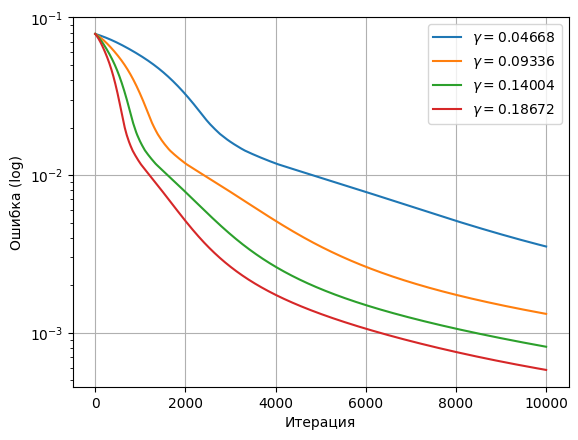

In [290]:
# Ваше решение (Code)

for gamma in gammas:

    _, _, err = mirror_extragradient(A, compute_gap, x_0, y_0, gamma=gamma, max_iter=10000)
    plt.plot(np.arange(len(err)), err, label=fr"$\gamma = {gamma:.5f}$")

plt.legend()
plt.xlabel("Итерация")
plt.ylabel("Ошибка (log)")
plt.yscale("log")
plt.grid()
plt.show()

Для лучшего шага визуализируйте вероятности нахождения вора и полицейского. 

In [291]:
x, y, err = mirror_extragradient(A, compute_gap, x_0, y_0, gamma=4/L, max_iter=10000)

100%|██████████| 10000/10000 [00:07<00:00, 1386.76it/s]


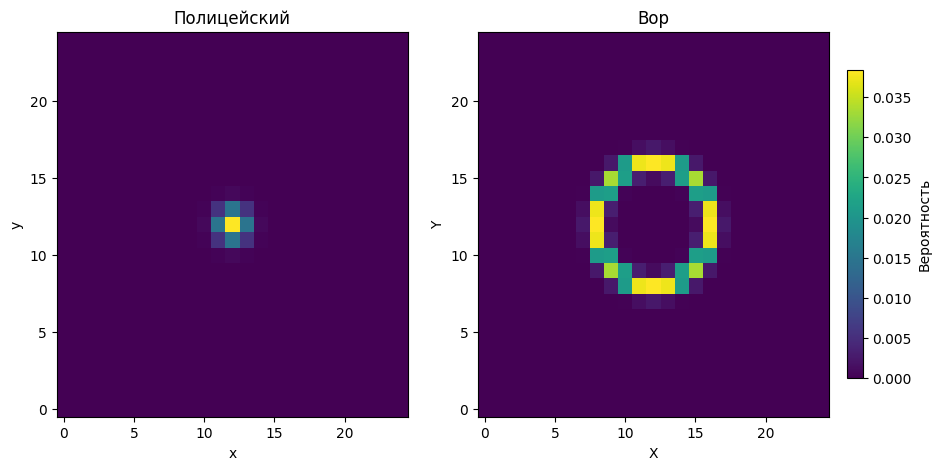

In [292]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(x.reshape(n, n), cmap='viridis', aspect='auto', origin='lower')
axes[0].set_title('Полицейский')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

im2 = axes[1].imshow(y.reshape(n, n), cmap='viridis', aspect='auto', origin='lower')
axes[1].set_title('Вор')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')

cbar = fig.colorbar(im2, ax=axes, orientation='vertical', shrink=0.8, pad=0.02)
cbar.set_label('Вероятность')

plt.show()